## 0. 전처리 완료된 데이터 불러오기

In [ ]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress
import platform

from pycaret.classification import *
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

In [3]:
# --- plt 한글 폰트 설정 ---
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 전처리 완료된 데이터 불러오기
df_preprocessed = pd.read_csv('data\smallbiz-data-final.csv', encoding='utf-8')
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86542 entries, 0 to 86541
Data columns (total 60 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   가맹점구분번호            86542 non-null  object 
 1   기준년월               86542 non-null  int64  
 2   가맹점 운영개월수 구간       86542 non-null  object 
 3   매출금액 구간            86542 non-null  object 
 4   매출건수 구간            86542 non-null  object 
 5   유니크 고객 수 구간        86542 non-null  object 
 6   객단가 구간             86542 non-null  object 
 7   취소율 구간             86542 non-null  object 
 8   배달매출금액 비율          86542 non-null  float64
 9   동일 업종 매출금액 비율      86542 non-null  float64
 10  동일 업종 매출건수 비율      86542 non-null  float64
 11  동일 업종 내 매출 순위 비율   86542 non-null  float64
 12  동일 상권 내 매출 순위 비율   86542 non-null  float64
 13  동일 업종 내 해지 가맹점 비중  86542 non-null  float64
 14  동일 상권 내 해지 가맹점 비중  86542 non-null  float64
 15  남성 20대이하 고객 비중     86542 non-null  float64
 16  남성 30대 고객 비중       865

#### 분석을 위한 추가적인 전처리

In [5]:
# 구간형 범주형 변수들을 1~6점 사이로 매핑해서 적용
# 적용할 범주의 점수
standard_map = {
    '1_10%이하': 1,
    '2_10-25%': 2,
    '3_25-50%': 3,
    '4_50-75%': 4,
    '5_75-90%': 5,
    '6_90%초과(하위 10% 이하)': 6
}
# 적용 컬럼
standard_cols = [
    '가맹점 운영개월수 구간',
    '매출금액 구간',
    '매출건수 구간',
    '유니크 고객 수 구간',
    '객단가 구간'
]
# 매핑 적용 - 새롭게 컬럼 생성
for col in standard_cols:
    new_col_name = f"{col}_score"
    df_preprocessed[new_col_name] = df_preprocessed[col].map(standard_map)

# 취소율은 거꾸로 매핑
cancle_map = {
    '1_상위1구간':6,
    '2_상위2구간':5,
    '3_상위3구간':4,
    '4_상위4구간':3,
    '5_상위5구간':2,
    '6_상위6구간(하위1구간)':1
}

# 적용 컬럼 및 매핑 적용
cancel_col = '취소율 구간'
cancel_col_score = f"{cancel_col}_score"
df_preprocessed[cancel_col_score] = df_preprocessed[cancel_col].map(cancle_map)

In [6]:
# 불필요한 원본 구간형 범주형 변수 제거
not_use_col = ['가맹점 운영개월수 구간','매출금액 구간','매출건수 구간','유니크 고객 수 구간',
               '객단가 구간','취소율 구간','가맹점주소','가맹점명','가맹점지역',]

df_preprocessed = df_preprocessed.drop(columns=not_use_col)

In [7]:
# 데이터 타입 변환
# 위도, 경도는 str -> float 변경
df_preprocessed['위도'] = pd.to_numeric(df_preprocessed['위도'], errors='coerce')
df_preprocessed['경도'] = pd.to_numeric(df_preprocessed['경도'], errors='coerce')

# 시간 데이터는 str -> datetime 변경
df_preprocessed['기준년월'] = pd.to_datetime(df_preprocessed['기준년월'].astype(str), format='%Y%m')
df_preprocessed['개설일'] = pd.to_datetime(df_preprocessed['개설일'], format='%Y-%m-%d', errors='coerce')
df_preprocessed['폐업일'] = pd.to_datetime(df_preprocessed['폐업일'], format='%Y-%m-%d', errors='coerce')

In [8]:
# 총운영일(기간) 컬럼 생성
# 마지막 날짜 설정 -> 관측의 마지막 일자
observation_end_date = pd.to_datetime('2024-12-31')

# 폐업일이 null인 경우(운영중)와 아닌 경우(폐업)로 나누기 위한 조건 설정
condition = df_preprocessed['폐업일'].isnull()

# np.where로 조건부 수식 설정
duration_timedelta = np.where(
    condition,
    observation_end_date - df_preprocessed['개설일'],       # True (운영중)
    df_preprocessed['폐업일'] - df_preprocessed['개설일']   # False (폐업)
)

# 총운영일 컬럼을 생성하고 반영
df_preprocessed['총운영일'] = pd.to_timedelta(duration_timedelta).days

# 혹시 모를 null값은 0처리, 그리고 int형 변환
df_preprocessed['총운영일'] = df_preprocessed['총운영일'].fillna(0)
df_preprocessed['총운영일'] = df_preprocessed['총운영일'].astype(int)

## 1. 경보를 알리는 feature 생성

In [9]:
# 경보 설정을 위해 원본 데이터 프레임을 복사하여 활용
df_alarm = df_preprocessed.copy()
df_alarm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86542 entries, 0 to 86541
Data columns (total 58 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   가맹점구분번호             86542 non-null  object        
 1   기준년월                86542 non-null  datetime64[ns]
 2   배달매출금액 비율           86542 non-null  float64       
 3   동일 업종 매출금액 비율       86542 non-null  float64       
 4   동일 업종 매출건수 비율       86542 non-null  float64       
 5   동일 업종 내 매출 순위 비율    86542 non-null  float64       
 6   동일 상권 내 매출 순위 비율    86542 non-null  float64       
 7   동일 업종 내 해지 가맹점 비중   86542 non-null  float64       
 8   동일 상권 내 해지 가맹점 비중   86542 non-null  float64       
 9   남성 20대이하 고객 비중      86542 non-null  float64       
 10  남성 30대 고객 비중        86542 non-null  float64       
 11  남성 40대 고객 비중        86542 non-null  float64       
 12  남성 50대 고객 비중        86542 non-null  float64       
 13  남성 60대이상 고객 비중      86542 non-null  float64   

#### 1) 1년 이내 폐업일이 존재 여부 판단

In [10]:
# 현 시점을 기준으로 1년 후 폐업 event가 발생하면 1, 아니면 0 레이블 생성
from dateutil.relativedelta import relativedelta

# 기준년월에서 1년후 날짜를 새롭게 생성
df_alarm['기준년월_Plus_1Y'] = df_alarm['기준년월'].apply(lambda x: x + relativedelta(months=12))

# 폐업 타겟 레이블 정의 (수정된 1년 기간 반영)
# 폐업일이 NaN이 아니면서, 기준년월_dt < 폐업일 <= 기준년월_Plus_1Y 조건을 만족하면 1
df_alarm['Target_폐업'] = np.where(
    (df_alarm['폐업일'].notna()) &
    (df_alarm['기준년월'] < df_alarm['폐업일']) &
    (df_alarm['폐업일'] <= df_alarm['기준년월_Plus_1Y']),
    1,
    0
)

#### 2) 매출급락이 6개월 이내 2단계 급락했는지 판단

In [11]:
# 현 시점을 기준으로 6개월 이내 매출금액 구간의 중앙값 구하기
rolling_median_6m = df_alarm.groupby('가맹점구분번호')['매출금액 구간_score'].rolling(window=6, min_periods=3).median()
df_alarm['매출구간_6M_Median'] = rolling_median_6m.reset_index(level=0, drop=True)

# 중앙값 대비 얼마나 하락했는지 비율 계산
df_alarm['구간_하락비율_Median'] = (df_alarm['매출구간_6M_Median'] - df_alarm['매출금액 구간_score']) / (df_alarm['매출구간_6M_Median'] + 1e-6)
# (선택) 중앙값 계산 불가(NaN) 등으로 인해 비율이 NaN이면 0으로 처리
df_alarm['구간_하락비율_Median'] = df_alarm['구간_하락비율_Median'].fillna(0)
# (선택) 비율이 음수면(오히려 상승) 0으로 처리 (하락만 관심 있으므로)
df_alarm['구간_하락비율_Median'] = df_alarm['구간_하락비율_Median'].clip(lower=0)


# --- 3. 급락 기준 정의 (예: 중앙값 대비 50% 이상 하락 시 급락) ---
PLUNGE_RATIO_THRESHOLD_MEDIAN = 0.5
df_alarm['Target_매출급락'] = np.where(
    df_alarm['구간_하락비율_Median'] >= PLUNGE_RATIO_THRESHOLD_MEDIAN,
    1,
    0
)

#### 3) 매출금액 구간이 6개월간 1, 2에 머물러 있는지 판단

In [12]:
# --- 1. '최근 6개월간 점수가 모두 낮았는지' 확인하는 함수 정의 ---
def check_all_low_score_6mo(series, min_periods=3):
    """
    입력된 Series (롤링 윈도우)의 모든 값이 1 또는 2인지 확인합니다.
    최소 min_periods 이상의 유효한 값이 있어야 1을 반환합니다.
    """
    # 유효한 값(NaN 제외)만 선택
    valid_series = series.dropna()
    # 최소 기간 충족 여부 확인
    if len(valid_series) < min_periods:
        return 0
    # 모든 유효한 값이 2 이하인지 확인
    if (valid_series <= 2).all():
        return 1
    else:
        return 0

# --- 2. 롤링 함수 적용하여 'Is_Low_Score_6mo' 컬럼 생성 ---
# window=6: 최근 6개월, min_periods=3: 최소 3개월 데이터 필요
# apply() 함수에 위에서 정의한 함수 전달 (raw=False: Series 객체로 전달)
df_alarm['Target_낮은매출'] = df_alarm.groupby('가맹점구분번호')['매출금액 구간_score'] \
                                     .rolling(window=6, min_periods=3) \
                                     .apply(check_all_low_score_6mo, raw=False) \
                                     .reset_index(level=0, drop=True) \
                                     .fillna(0) # rolling 초반 NaN 처리

#### 4) 앞선 1, 2, 3 지표들 중 한개라도 포함이 되면 위험 경보라고 판단 => Target_Final

In [13]:
df_alarm['Target_Final'] = np.where(
    # 각 조건을 ( ) 로 명확히 묶어줍니다.
    (df_alarm['Target_폐업'] == 1) |
    (df_alarm['Target_매출급락'] == 1) |
    (df_alarm['Target_낮은매출'] == 1),
    1, # 위 세 조건 중 하나라도 True이면 1
    0  # 모두 False이면 0
)

In [157]:
df_alarm[df_alarm['Target_Final'] == 1]

79       1
80       1
81       1
82       1
91       1
        ..
86537    1
86538    1
86539    1
86540    1
86541    1
Name: Target_Final, Length: 14330, dtype: int32

#### 5) 만든 Target_Final 지표를 원본 df_preprocessed에 붙이기

In [14]:
# 최종 타겟 컬럼만 추출
df_alarm_subset = df_alarm[['가맹점구분번호', '기준년월', 'Target_Final']].copy()

# 원본 전처리 데이터프레임에 최종 타겟 컬럼 병합
df = pd.merge(
    df_preprocessed,
    df_alarm_subset,
    on=['가맹점구분번호', '기준년월'],
    how='left'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86542 entries, 0 to 86541
Data columns (total 59 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   가맹점구분번호             86542 non-null  object        
 1   기준년월                86542 non-null  datetime64[ns]
 2   배달매출금액 비율           86542 non-null  float64       
 3   동일 업종 매출금액 비율       86542 non-null  float64       
 4   동일 업종 매출건수 비율       86542 non-null  float64       
 5   동일 업종 내 매출 순위 비율    86542 non-null  float64       
 6   동일 상권 내 매출 순위 비율    86542 non-null  float64       
 7   동일 업종 내 해지 가맹점 비중   86542 non-null  float64       
 8   동일 상권 내 해지 가맹점 비중   86542 non-null  float64       
 9   남성 20대이하 고객 비중      86542 non-null  float64       
 10  남성 30대 고객 비중        86542 non-null  float64       
 11  남성 40대 고객 비중        86542 non-null  float64       
 12  남성 50대 고객 비중        86542 non-null  float64       
 13  남성 60대이상 고객 비중      86542 non-null  float64   

## 2. 생존분석 기법으로 DF를 분석

#### 1) Feature Engineering

In [26]:
# 정적 변수
static_cols = ['가맹점구분번호', '기준년월', '브랜드구분코드', '업종', '상권', '개설일', '폐업일', '경도', '위도', '법정동', '폐업여부', '총운영일']

# 동적 변수
# 핵심 동적 변수 지표
core_cols = [
    '매출금액 구간_score',
    '매출건수 구간_score',
    '유니크 고객 수 구간_score',
    '객단가 구간_score',
    '재방문 고객 비중',
    '신규 고객 비중',
    '동일 업종 내 매출 순위 비율',
    '동일 상권 내 매출 순위 비율',
    'Target_Final', # Assuming this is used for historical analysis as a feature
    '취소율 구간_score',
    '동일 업종 내 해지 가맹점 비중',
    '동일 상권 내 해지 가맹점 비중'
]

# 보조 동적 변수 지표
sub_cols = [
    # 배달 관련
    '배달매출금액 비율',
    # 업종 평균 대비
    '동일 업종 매출금액 비율',
    '동일 업종 매출건수 비율',
    # 운영 기간
    '가맹점 운영개월수 구간_score',
    # 세부 고객 구성
    '남성 20대이하 고객 비중',
    '남성 30대 고객 비중',
    '남성 40대 고객 비중',
    '남성 50대 고객 비중',
    '남성 60대이상 고객 비중',
    '여성 20대이하 고객 비중',
    '여성 30대 고객 비중',
    '여성 40대 고객 비중',
    '여성 50대 고객 비중',
    '여성 60대이상 고객 비중',
    '거주 이용 고객 비율',
    '직장 이용 고객 비율',
    '유동인구 이용 고객 비율',
    # 직접 합산한 고객 그룹
    '20대이하',
    '30대',
    '40대',
    '50대',
    '60대이상',
    '남성합계비율',
    '여성합계비율',
    '2030합비율',
    '405060합비율',
    # 거시 경제 지표
    '경제활동참가율_합계',
    '경제활동참가율_남자',
    '경제활동참가율_여자',
    '실업률_합계',
    '실업률_남자',
    '실업률_여자',
    '고용률_합계',
    '고용률_남자',
    '고용률_여자'
]

In [16]:
# 정적변수로만 구성된 DF 생성
# 그룹으로 묶을 키랑, 제외할 컬럼 설정
grouping_key = '가맹점구분번호'
exclude_from_agg = [grouping_key, '기준년월'] # 기준년월은 first로 가져올 필요 없음

# 딕셔너리 컴프리헨션으로 집계 사전 생성
agg_dict = {
    col: (col, 'first') # 새 컬럼 이름 = (원본 컬럼 이름, 집계 함수)
    for col in static_cols # static_cols 리스트를 순회하며
    if col not in exclude_from_agg # 제외 컬럼이 아닌 경우에만 사전에 추가
}

# 딕셔너리 기반 그룹화
df_static = df.groupby(grouping_key).agg(**agg_dict).reset_index()
df_static

,가맹점구분번호,브랜드구분코드,업종,상권,개설일,폐업일,경도,위도,법정동,폐업여부,총운영일
0,000F03E44A,독립,중식-딤섬/중식만두,뚝섬,2022-02-25,NaT,127.046360,37.545437,성수동1가,0,1040
1,002816BA73,독립,요리주점,마장동,2014-05-07,NaT,127.037101,37.570102,마장동,0,3891
2,003473B465,독립,백반/가정식,뚝섬,2019-05-07,NaT,127.043636,37.548198,성수동1가,0,2065
3,003AC99735,커피전문점2,커피전문점,답십리,2019-10-17,NaT,127.053782,37.564381,용답동,0,1902
4,0041E4E5AE,독립,한식-찌개/전골,답십리,2018-01-15,NaT,127.052844,37.563932,용답동,0,2542
...,...,...,...,...,...,...,...,...,...,...,...
4178,FFAC8CC0F7,독립,한식-국밥/설렁탕,성수,2009-04-24,NaT,127.054524,37.548389,성수동2가,0,5730
4179,FFD5654C3D,독립,한식-찌개/전골,한양대,2011-02-18,NaT,127.039582,37.560278,행당동,0,5065
4180,FFE9F1CC6A,독립,백반/가정식,답십리,2024-11-28,NaT,127.052320,37.563490,용답동,0,33
4181,FFEDAC5747,베이커리10,베이커리,정보없음,2019-01-10,NaT,127.035483,37.558221,행당동,0,2182


In [18]:
# 동적 변수에 적용할 함수들
# 추세, 기울기를 계산하는 커스텀 함수
def calculate_trend(series):
    '''
    한 컬럼을 대상으로 추세선(기울기)를 구하는 함수
    '''
    # 기준년월 대신 0,1,2,... 순서로 x축 사용
    y = series.values
    x = np.arange(len(y))

    # 결측치가 있으면 기울기 계산이 불가함으로 0으로 처리
    if len(y) < 2 or np.isnan(y).any():
        return 0
    
    # linregress는 기울기(slope)를 반환
    slope, _, _, _, _ = linregress(x, y)
    return slope

# 최근 6개월 추세 계산 함수
def calculate_recent_trend(series, months=6):
    series = series.tail(months) # 최근 6개월 데이터만 선택
    return calculate_trend(series)

# 전월 대비 변화량 평균
def mean_absolute_change(series):
    if series.isnull().any():
        return np.nan # 결측치 있으면 계산 스킵
    return series.diff().abs().mean()

In [27]:
# 3. 집계 사전 생성 (차등 적용)
agg_dict = {}

# 3-1. 핵심 지표에 대한 전체 집계
print(f"핵심 지표 ({len(core_cols)}개)에 전체 집계 적용...")
for col in core_cols:
    
    if col == 'Target_Final':
        continue  # Target_Final은 집계에서 제외
                                                            # 모든 변수는 동일하게 적용
    agg_dict[f'avg_{col}'] = (col, 'mean')                  # 평균
    agg_dict[f'std_{col}'] = (col, 'std')                   # 표준편차
    agg_dict[f'trend_{col}'] = (col, calculate_trend)       # 추세(기울기)
    
    if col.endswith('_score'):                              # 점수형 변수에 한해 추가 집계
        agg_dict[f'median_{col}'] = (col, 'median')         # 중앙값
        agg_dict[f'count_low_{col}'] = (col, lambda x: (x <= 2).sum())  # 낮은 점수 개수
        agg_dict[f'count_high_{col}'] = (col, lambda x: (x == 6).sum()) # 높은 점수 개수

    else:                                                   # 일반 수치형 변수에 한해 추가 집계
        agg_dict[f'min_{col}'] = (col, 'min')               # 최소값
        agg_dict[f'max_{col}'] = (col, 'max')               # 최대값


# 3-2. 보조 지표에 대한 기본 집계
print(f"보조 지표 ({len(sub_cols)}개)에 기본 집계 적용...")
for col in sub_cols:
    agg_dict[f'avg_{col}'] = (col, 'mean')
    agg_dict[f'std_{col}'] = (col, 'std')
    agg_dict[f'trend_{col}'] = (col, calculate_trend)


# 3-3. Target_Final 집계 (경고 횟수)
if 'Target_Final' in df.columns:
     agg_dict['warning_count'] = ('Target_Final', lambda x: (x == 1).sum())


# 4. 집계 실행
df_dynamic = df.groupby('가맹점구분번호').agg(**agg_dict).reset_index()
df_dynamic = df_dynamic.fillna(0) # 결측치 처리

핵심 지표 (12개)에 전체 집계 적용...
보조 지표 (35개)에 기본 집계 적용...
총 166개의 동적 파생 변수를 생성합니다.
가맹점별 요약 데이터 집계(Aggregation)를 시작합니다...
✅ 동적 파생 변수 생성 완료 (선택적 집계 적용)!
      가맹점구분번호  avg_매출금액 구간_score  std_매출금액 구간_score  trend_매출금액 구간_score  \
0  000F03E44A           5.750000           0.442326            -0.029565   
1  002816BA73           3.000000           0.294884             0.005217   
2  003473B465           5.833333           0.380693             0.031304   
3  003AC99735           2.250000           0.442326            -0.007826   
4  0041E4E5AE           2.083333           0.282330             0.012174   

   median_매출금액 구간_score  count_low_매출금액 구간_score  count_high_매출금액 구간_score  \
0                   6.0                        0                        18   
1                   3.0                        1                         0   
2                   6.0                        0                        20   
3                   2.0                       18                         0   
4         

In [ ]:
# 정적과 동적 변수를 합한 최종 생존 데이터프레임
df_survive = pd.merge(df_static, df_dynamic, on='가맹점구분번호', how='left')

,가맹점구분번호,브랜드구분코드,업종,상권,개설일,폐업일,경도,위도,법정동,폐업여부,...,avg_고용률_합계,std_고용률_합계,trend_고용률_합계,avg_고용률_남자,std_고용률_남자,trend_고용률_남자,avg_고용률_여자,std_고용률_여자,trend_고용률_여자,warning_count
0,000F03E44A,독립,중식-딤섬/중식만두,뚝섬,2022-02-25,NaT,127.046360,37.545437,성수동1가,0,...,61.404167,0.564515,0.056826,69.00,0.562603,0.014261,54.554167,0.8081,0.092217,0
1,002816BA73,독립,요리주점,마장동,2014-05-07,NaT,127.037101,37.570102,마장동,0,...,61.404167,0.564515,0.056826,69.00,0.562603,0.014261,54.554167,0.8081,0.092217,0
2,003473B465,독립,백반/가정식,뚝섬,2019-05-07,NaT,127.043636,37.548198,성수동1가,0,...,61.404167,0.564515,0.056826,69.00,0.562603,0.014261,54.554167,0.8081,0.092217,0
3,003AC99735,커피전문점2,커피전문점,답십리,2019-10-17,NaT,127.053782,37.564381,용답동,0,...,61.404167,0.564515,0.056826,69.00,0.562603,0.014261,54.554167,0.8081,0.092217,8
4,0041E4E5AE,독립,한식-찌개/전골,답십리,2018-01-15,NaT,127.052844,37.563932,용답동,0,...,61.404167,0.564515,0.056826,69.00,0.562603,0.014261,54.554167,0.8081,0.092217,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4178,FFAC8CC0F7,독립,한식-국밥/설렁탕,성수,2009-04-24,NaT,127.054524,37.548389,성수동2가,0,...,61.404167,0.564515,0.056826,69.00,0.562603,0.014261,54.554167,0.8081,0.092217,0
4179,FFD5654C3D,독립,한식-찌개/전골,한양대,2011-02-18,NaT,127.039582,37.560278,행당동,0,...,61.404167,0.564515,0.056826,69.00,0.562603,0.014261,54.554167,0.8081,0.092217,0
4180,FFE9F1CC6A,독립,백반/가정식,답십리,2024-11-28,NaT,127.052320,37.563490,용답동,0,...,61.400000,0.282843,-0.400000,68.55,0.636396,-0.900000,54.900000,0.0000,0.000000,0
4181,FFEDAC5747,베이커리10,베이커리,정보없음,2019-01-10,NaT,127.035483,37.558221,행당동,0,...,61.404167,0.564515,0.056826,69.00,0.562603,0.014261,54.554167,0.8081,0.092217,22


#### 2) 상관계수 분석

총 166개의 숫자형 피처로 상관관계를 분석합니다.


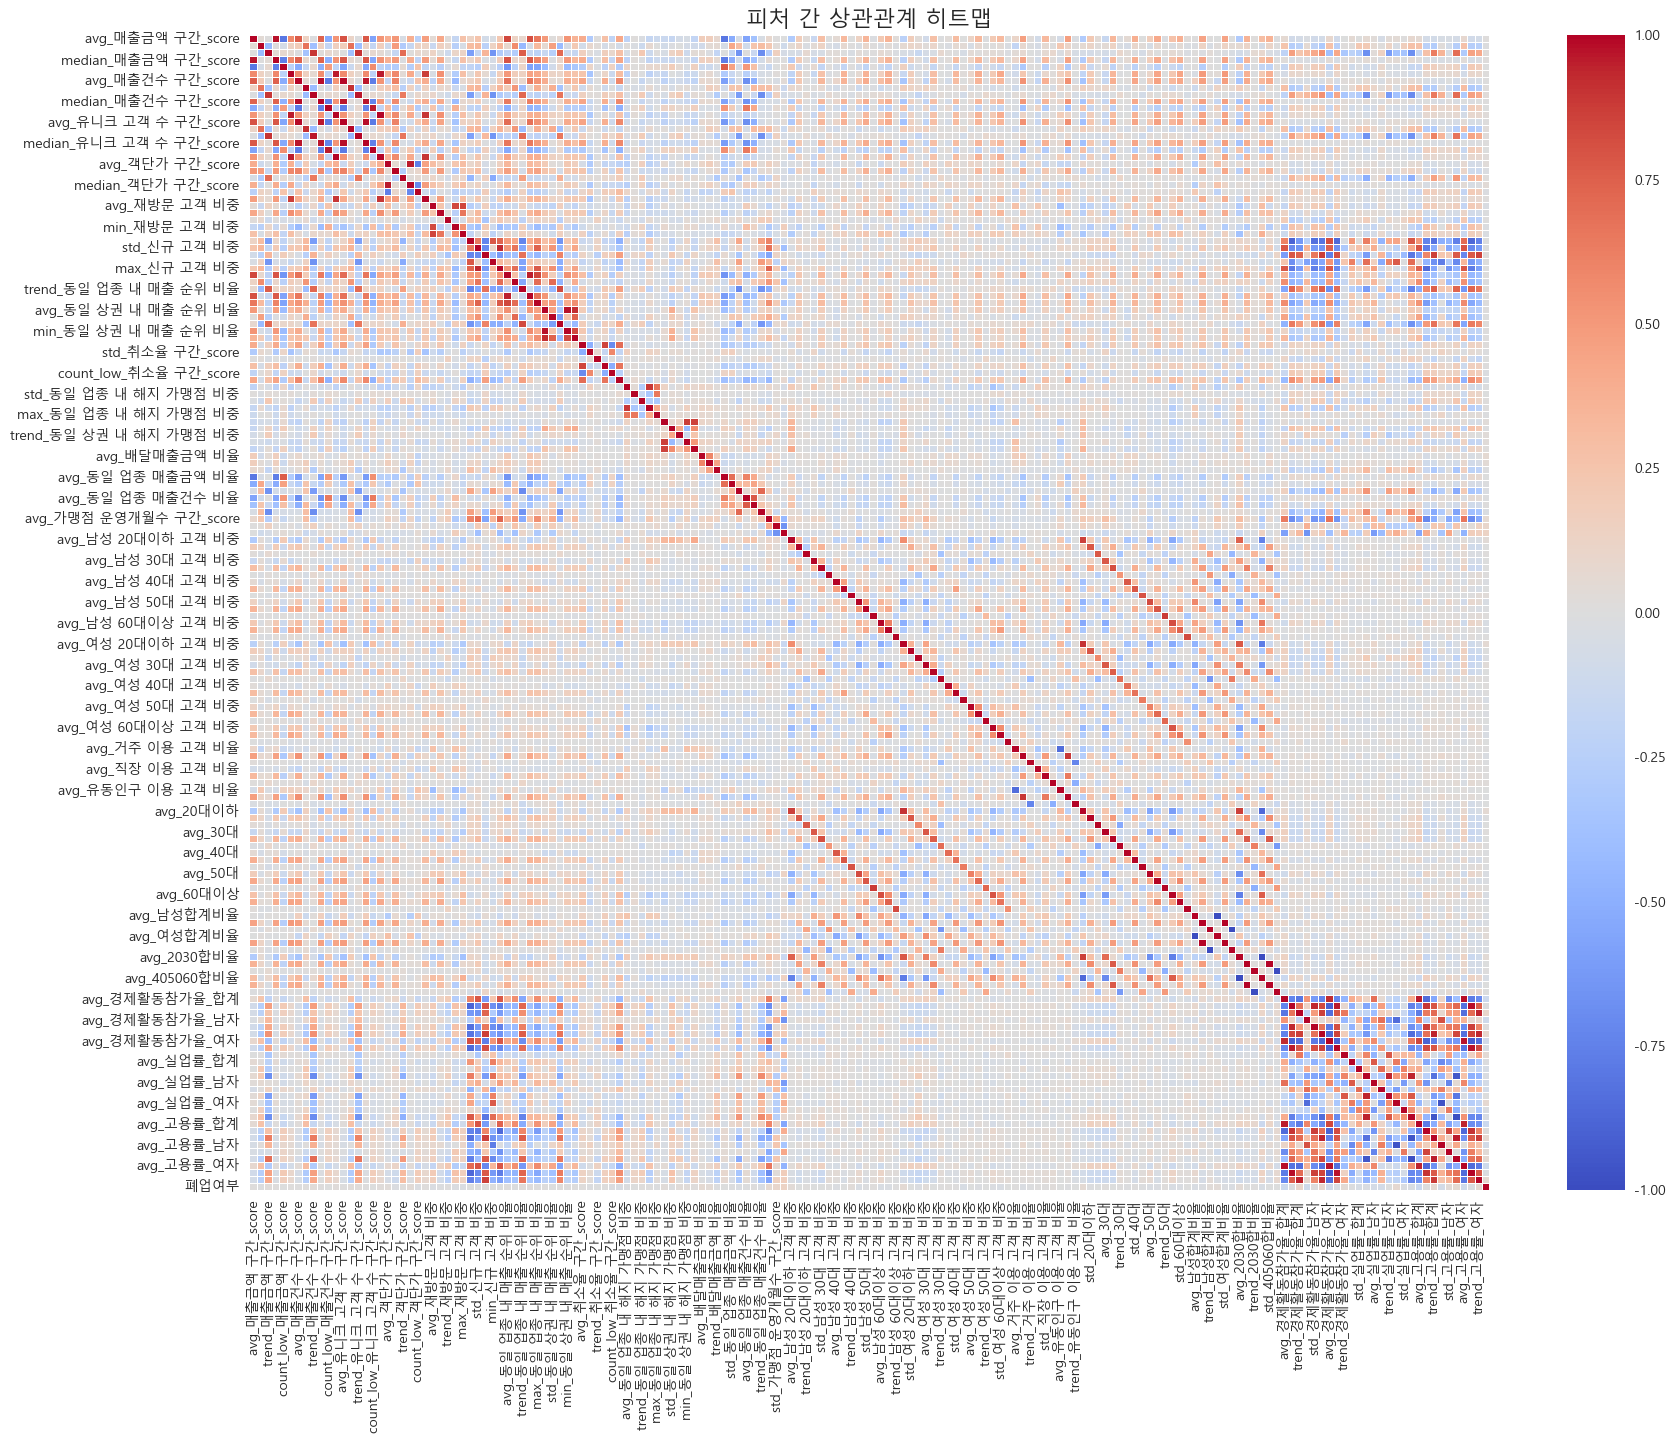


--- '폐업여부'와의 상관관계 (높은 순) ---
폐업여부                        1.000000
trend_가맹점 운영개월수 구간_score    0.132314
std_가맹점 운영개월수 구간_score      0.093202
trend_경제활동참가율_합계            0.087632
trend_경제활동참가율_남자            0.084534
trend_고용률_여자                0.067283
avg_실업률_여자                  0.067165
trend_고용률_합계                0.065968
trend_고용률_남자                0.057109
avg_배달매출금액 비율               0.055588
Name: 폐업여부, dtype: float64

--- '폐업여부'와의 상관관계 (낮은 순 / 음의 상관) ---
avg_고용률_합계           -0.125765
avg_경제활동참가율_합계       -0.119883
avg_고용률_여자           -0.108201
avg_경제활동참가율_남자       -0.105356
avg_경제활동참가율_여자       -0.092426
avg_고용률_남자           -0.074232
std_실업률_남자           -0.074190
avg_실업률_남자           -0.069690
std_실업률_합계           -0.050186
trend_여성 40대 고객 비중   -0.045904
Name: 폐업여부, dtype: float64


In [31]:
# 숫자형이면서, 분석에 의미 있는 피처 컬럼들을 선택합니다.
potential_features = [
    col for col in df_survive.columns
    if col.startswith(('avg_', 'std_', 'last_', 'min_', 'max_', 'trend_', 'median_', 'q25_', 'q75_', 'count_', 'change_'))
]

# (안전장치) df_survival에 실제로 존재하는 숫자형 컬럼만 선택
numeric_features = df_survive[potential_features].select_dtypes(include=np.number).columns.tolist()

# (선택) 타겟 변수('폐업여부')도 포함하여 상관관계 보기
if '폐업여부' in df_survive.columns and '폐업여부' not in numeric_features:
     numeric_features.append('폐업여부')


print(f"총 {len(numeric_features)}개의 숫자형 피처로 상관관계를 분석합니다.")
df_corr_input = df_survive[numeric_features]

# --- 4. 상관관계 행렬 계산 ---
correlation_matrix = df_corr_input.corr()

# --- 5. 히트맵 시각화 ---
plt.figure(figsize=(20, 15)) # 히트맵 크기 조절 (피처 수에 따라)
sns.heatmap(correlation_matrix,
            annot=False,       # 주석(숫자) 표시 여부 (너무 많으면 False)
            cmap='coolwarm',   # 색상 맵 (coolwarm: 음수는 파랑, 양수는 빨강)
            linewidths=0.5,    # 셀 간 구분선
            fmt=".2f")         # 주석 표시 형식 (소수점 둘째 자리)
plt.title('피처 간 상관관계 히트맵', fontsize=16)
plt.show()

# --- (선택) 특정 변수와의 상관관계만 확인 ---
# 예: '폐업여부'와 다른 변수들 간의 상관관계만 정렬하여 보기
if '폐업여부' in correlation_matrix.columns:
    print("\n--- '폐업여부'와의 상관관계 (높은 순) ---")
    print(correlation_matrix['폐업여부'].sort_values(ascending=False).head(10))
    print("\n--- '폐업여부'와의 상관관계 (낮은 순 / 음의 상관) ---")
    print(correlation_matrix['폐업여부'].sort_values(ascending=True).head(10))

#### 3) 캐플린-마이어 기법으로 확인하는 생존곡선

In [ ]:
# 복제본을 만들어서 캐플린-마이어 생존곡선 확인
df_survive2 = df_survive.copy()

In [ ]:
df_survive2

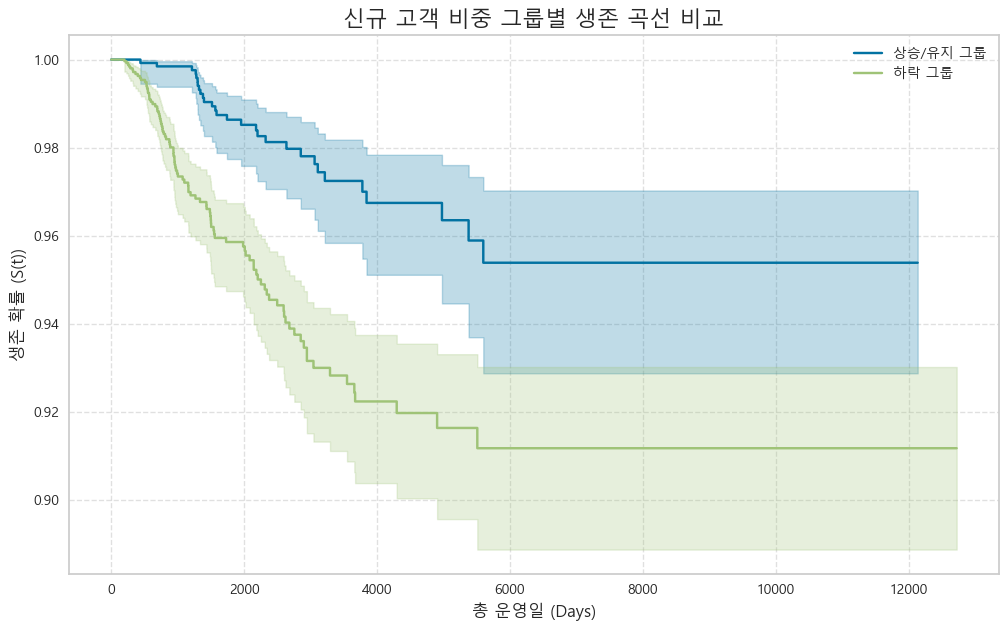

In [175]:
# 카플란-마이어(Kaplan-Meier) 생존 곡선 시각화
# 1. 'trend_sales_score' (매출 추세)를 기준으로 두 그룹으로 나눕니다.
#    (0을 기준으로 하락/상승을 나눔)
df_survive2['sales_trend_group'] = (df_survive2['trend_신규 고객 비중'] > 0).map(
    {True: '상승/유지 그룹', False: '하락 그룹'}
)

# 2. 그룹별로 KMF 모델 객체 생성
kmf_up = KaplanMeierFitter()
kmf_down = KaplanMeierFitter()

# 3. 그룹별 데이터 분리
df_up = df_survive2[df_survive2['sales_trend_group'] == '상승/유지 그룹']
df_down = df_survive2[df_survive2['sales_trend_group'] == '하락 그룹']

# 4. 모델 학습 (T: 총운영일, E: is_closed)
kmf_up.fit(df_up['총운영일'], event_observed=df_up['폐업여부'], label='상승/유지 그룹')
kmf_down.fit(df_down['총운영일'], event_observed=df_down['폐업여부'], label='하락 그룹')

# 5. 그래프 시각화
plt.figure(figsize=(12, 7))
ax = kmf_up.plot_survival_function()
kmf_down.plot_survival_function(ax=ax)
plt.title('신규 고객 비중 그룹별 생존 곡선 비교', fontsize=16)
plt.xlabel('총 운영일 (Days)', fontsize=12)
plt.ylabel('생존 확률 (S(t))', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### 4) 콕스 비례 위험 모델

In [43]:
# 분석하기 전 카피하여 사용
df_survive3 = df_survive.copy()

In [75]:
df_survive3.drop('sales_trend_group', axis=1, inplace=True)

In [84]:
# 1. (중요) 범주형 변수(업종, 상권)를 더미 변수로 변환
#    (예: '업종_한식', '업종_카페' 컬럼이 0 또는 1의 값을 갖게 됨)
df_cox_input = pd.get_dummies(
    df_survive3, 
    columns=['업종', '상권'], 
    drop_first=True # 기준이 되는 카테고리 하나는 제거하여 다중공선성 방지
)

# 3. 모델에 사용할 컬럼만 선택
#    (날짜, ID, 문자열 등 불필요한 컬럼 제외)
#    비교하는 컬럼들이 너무 적으면 비슷한 경향을 보여 츨력이 안됨
features = ['총운영일', '폐업여부']
sub_dynamic = [col for col in df_cox_input.columns if '매출' in col]
features.extend(sub_dynamic)

# df_cox_input에서 더미 변수 이름들을 확인하고 features 리스트에 추가해야 합니다.
dummy_cols = [col for col in df_cox_input.columns if '업종_' in col or '상권_' in col]
features.extend(dummy_cols)

df_cox_final_input = df_cox_input[features]

In [85]:
# 1. 콕스 모델 객체 생성
cph = CoxPHFitter()

# 2. 모델 학습
#    T = '총운영일', E = '폐업여부'
cph.fit(df_cox_final_input, duration_col='총운영일', event_col='폐업여부')

# 3. (결과) '위험 지수' 요약표 출력
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 4183 total observations, 4056 right-censored observations>
             duration col = '총운영일'
                event col = '폐업여부'
      baseline estimation = breslow
   number of observations = 4183
number of events observed = 127
   partial log-likelihood = -818.71
         time fit was run = 2025-10-23 18:20:04 UTC

---
                           coef  exp(coef)    se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                         
avg_매출금액 구간_score         -0.12       0.89        0.62            -1.34             1.10                 0.26                 3.01
std_매출금액 구간_score         -0.08       0.92        0.54            -1.15             0.99                 0.32                 2.68
trend_매출금액 구간_score       -1.71       0.18        3.10            -7.78             4.37                 0.00                78.74
median_매출금액 구간_score       0.05       1.05        0.36            -0.66             0.76                 0.52                 2.13
count_low_매출금액 구간_score    0.01       1.01        0.03            -0.05             0.07                 0.95                 1.07
count_high_매출금액 구간_score  -0.21       0.81        0.10            -0.40            -0.02                 0.67                 0.98
avg_매출건수 구간_score         -0.32       0.72        0.46            -1.22             0.57                 0.30                 1.77
std_매출건수 구간_score          0.29       1.34        0.42            -0.53             1.11                 0.59                 3.04
trend_매출건수 구간_score        4.14      62.76        1.51             1.18             7.09                 3.27              1204.45
median_매출건수 구간_score       0.21       1.23        0.33            -0.45             0.86                 0.64                 2.36
count_low_매출건수 구간_score   -0.02       0.98        0.02            -0.06             0.03                 0.94                 1.03
count_high_매출건수 구간_score   0.22       1.24        0.10             0.02             0.42                 1.02                 1.52
avg_동일 업종 내 매출 순위 비율      -0.09       0.92        0.04            -0.17            -0.00                 0.84                 1.00
std_동일 업종 내 매출 순위 비율       0.06       1.07        0.09            -0.12             0.25                 0.89                 1.28
trend_동일 업종 내 매출 순위 비율    -0.88       0.42        0.17            -1.21            -0.54                 0.30                 0.58
min_동일 업종 내 매출 순위 비율       0.10       1.10        0.05            -0.01             0.20                 0.99                 1.22
max_동일 업종 내 매출 순위 비율       0.01       1.01        0.03            -0.05             0.06                 0.95                 1.06
avg_동일 상권 내 매출 순위 비율       0.05       1.05        0.06            -0.06             0.17                 0.94                 1.18
std_동일 상권 내 매출 순위 비율      -0.02       0.98        0.14            -0.30             0.26                 0.74                 1.30
trend_동일 상권 내 매출 순위 비율    -0.32       0.73        0.23            -0.77             0.14                 0.46                 1.15
min_동일 상권 내 매출 순위 비율      -0.04       0.96        0.07            -0.18             0.11                 0.83                 1.12
max_동일 상권 내 매출 순위 비율      -0.00       1.00        0.04            -0.08             0.08                 0.92                 1.08
avg_배달매출금액 비율              0.02       1.02        0.01             0.01             0.03                 1.01                 1.03
std_배달매출금액 비율              0.01       1.01        0.02            -0.02             0.05                 0.98                 1.05
trend_배달매출금액 비율           -0.07       0.93        0.06            -0.19             0.05                 0.83                 1.06
avg_동일 업종 매출금액 비율          0.00       1.00        0.00            -0.00             0.01                

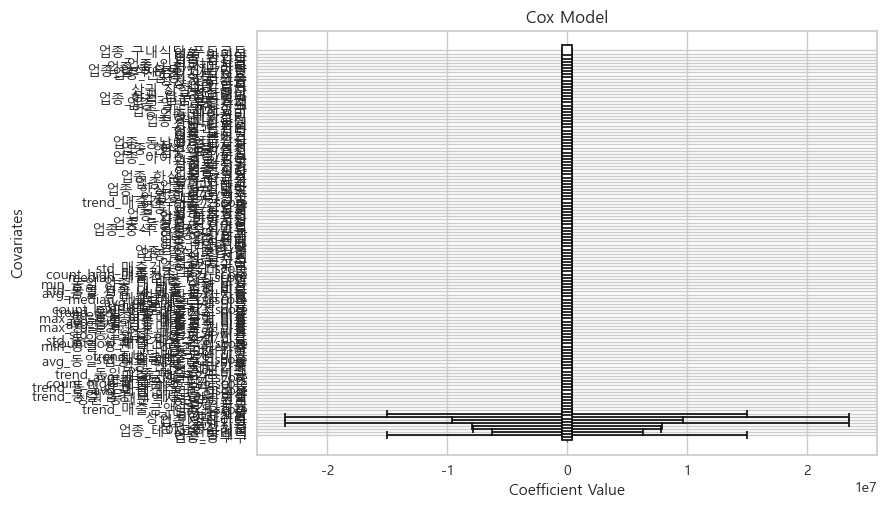

In [ ]:
n_vars = len(cph.summary)
fig_height = max(6, n_vars * 0.25)  # 변수 하나당 약 0.25인치 높이
fig, ax = plt.subplots(figsize=(8, fig_height))
cph.plot(ax=ax)
ax.set_title("Cox Model")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Covariates")
ax.grid(True)
plt.tight_layout()
plt.show()

#### 5) 분석 모델 선정

In [88]:
# 복사하고 사용
df2 = df.copy()

##### 1) y 설정

In [97]:
# y값 설정
# '미래의 y' 생성 - 일단 6개월 후의 미래를 예측
g = df2.groupby('가맹점구분번호')['폐업여부']
shifts = [g.shift(-i) for i in range(1, 7)]
df2['y_6개월후_폐업유무'] = pd.DataFrame(shifts).max(axis=0).fillna(0).astype(int)


# 1. 가맹점별로 그룹화 (Target_Final 기준)
g_target = df2.groupby('가맹점구분번호')['Target_Final']
# 2. 미래 1개월 ~ 6개월 뒤의 Target_Final 값을 가져옴
shifts = [g_target.shift(-i) for i in range(1, 7)] # 1부터 6까지
# 3. 가져온 6개의 미래 시점 값들을 DataFrame으로 묶음
future_targets_df = pd.DataFrame(shifts).transpose()
# 4. 6개의 미래 시점 값들을 모두 더함 (.sum(axis=1)) ✨<-- 변경된 부분 ✨
#    NaN은 0으로 채워서 계산
y_sum_in_6mo = future_targets_df.fillna(0).sum(axis=1)
# 5. 결과를 df에 새로운 컬럼으로 추가 (정수 타입으로)
df2['y_6개월후_경고수치'] = y_sum_in_6mo.astype(int)

##### 2) X 설정

In [98]:
# X값 설정
for col in core_cols:

    if col == 'Target_Final':
        continue  # Target_Final은 제외

    g = df.groupby('가맹점구분번호')[col]

    # 1개월 전 값
    df2[f'X_{col}_lag1'] = g.shift(1)

    # 과거 3개월 평균 (1개월 전 기준)
    avg_3m = g.rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df2[f'X_{col}_avg_3m_lag1'] = avg_3m.shift(1)
    
    # 과거 6개월 추세 (1개월 전 기준)
    trend_6m = g.rolling(window=6, min_periods=3).apply(calculate_trend, raw=False).reset_index(level=0, drop=True)
    df2[f'X_{col}_trend_6m_lag1'] = trend_6m.shift(1)

##### 3) 폐업일을 예측

In [99]:
# 4-1. 모델에 사용할 컬럼만 선택 - 피쳐 별

# 정적 변수
static_features = ['가맹점구분번호','업종', '상권']
# 동적 변수
dynamic_features = [col for col in df2.columns if col.startswith('X_')]
# 예측할 목표로 하는 값
target = ['y_6개월후_폐업유무']

df_model_input = df2[static_features + dynamic_features + target].copy()

# 4-2. (✨가장 중요✨) 과거/미래를 계산할 수 없는 'NaN' 행 제거
# (초반 6개월 'warm-up' 기간, 마지막 6개월 'cool-down' 기간이 제거됨)
df_prepared = df_model_input.dropna()

In [107]:
# 5-1. PyCaret 환경 설정
clf_setup = setup(
    data=df_prepared, 
    target='y_6개월후_폐업유무',
    session_id=123,
    categorical_features=['업종', '상권'], # 범주형 변수 지정
    ignore_features=['가맹점구분번호'],
    fix_imbalance=True,          # 불균형 데이터 처리 (SMOTE)
    verbose=False                # 로그 최소화
)

# 5-2. 모델 비교 (Recall: 위기를 놓치지 않는 순서로 정렬)
best_model = compare_models(sort='Recall')
best_model

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.0329,0.6089,0.9984,0.0250,0.0487,0.0003,0.0117,0.2270
qda,Quadratic Discriminant Analysis,0.0310,0.5657,0.9984,0.0249,0.0486,0.0002,0.0100,0.4680
knn,K Neighbors Classifier,0.9501,0.9457,0.8810,0.3178,0.4670,0.4469,0.5119,3.0640
et,Extra Trees Classifier,0.9914,0.9941,0.6960,0.9430,0.8008,0.7965,0.8062,2.5580
catboost,CatBoost Classifier,0.9904,0.9879,0.6501,0.9434,0.7693,0.7646,0.7787,13.5520
lda,Linear Discriminant Analysis,0.6884,0.7022,0.5989,0.0469,0.0870,0.0430,0.0968,0.5630
lr,Logistic Regression,0.6844,0.7048,0.5982,0.0463,0.0859,0.0418,0.0949,7.4670
ridge,Ridge Classifier,0.6880,0.7019,0.5981,0.0468,0.0868,0.0428,0.0964,0.2190
svm,SVM - Linear Kernel,0.6304,0.6387,0.5264,0.0489,0.0798,0.0388,0.0685,1.9720
rf,Random Forest Classifier,0.9871,0.9890,0.5008,0.9613,0.6574,0.6516,0.6883,5.8860


GaussianNB(priors=None, var_smoothing=1e-09)

##### 4) KNN 모델 최적화 및 혼동행렬

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9485,0.9521,0.8837,0.3115,0.4606,0.4400,0.5071
1,0.9501,0.9388,0.8605,0.3153,0.4615,0.4412,0.5033
2,0.9487,0.9420,0.8837,0.3123,0.4615,0.4410,0.5079
3,0.9499,0.9360,0.8906,0.3167,0.4672,0.4471,0.5140
4,0.9504,0.9439,0.8672,0.3162,0.4635,0.4433,0.5063
5,0.9520,0.9592,0.8828,0.3256,0.4758,0.4562,0.5194
6,0.9535,0.9620,0.9062,0.3362,0.4905,0.4715,0.5361
7,0.9499,0.9365,0.8527,0.3134,0.4583,0.4379,0.4991
8,0.9456,0.9316,0.8760,0.2982,0.4449,0.4235,0.4927


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9136,0.9737,0.9302,0.2147,0.3488,0.3214,0.4236
1,0.9262,0.9715,0.8992,0.2387,0.3772,0.3518,0.4415
2,0.9165,0.9837,0.9535,0.2236,0.3623,0.3355,0.4396
3,0.9260,0.9767,0.9453,0.2430,0.3866,0.3615,0.4586
4,0.9221,0.9874,0.9531,0.2346,0.3765,0.3508,0.4517
5,0.9287,0.9744,0.9453,0.2500,0.3954,0.3709,0.4659
6,0.9290,0.9787,0.9531,0.2521,0.3987,0.3743,0.4702
7,0.9180,0.9685,0.9147,0.2218,0.3570,0.3302,0.4275
8,0.9202,0.9727,0.9070,0.2254,0.3611,0.3346,0.4294


Fitting 10 folds for each of 10 candidates, totalling 100 fits


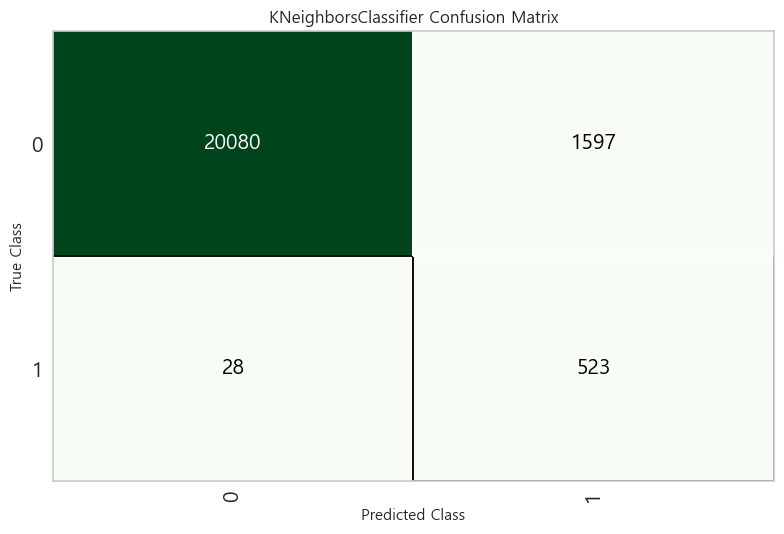

In [108]:
tuned_knn = tune_model(create_model('knn'), optimize='Recall')
plot_model(tuned_knn, plot='confusion_matrix')

##### 5) Extra Tree 모델 최적화 및 혼동행렬

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9904,0.9950,0.6744,0.9158,0.7768,0.7720,0.7814
1,0.9921,0.9904,0.7132,0.9583,0.8178,0.8138,0.8231
2,0.9911,0.9927,0.6977,0.9278,0.7965,0.7920,0.8004
3,0.9923,0.9921,0.7188,0.9583,0.8214,0.8176,0.8264
4,0.9933,0.9983,0.7500,0.9697,0.8458,0.8424,0.8497
5,0.9915,0.9989,0.6953,0.9468,0.8018,0.7976,0.8075
6,0.9911,0.9907,0.6875,0.9362,0.7928,0.7884,0.7982
7,0.9904,0.9955,0.6667,0.9247,0.7748,0.7700,0.7808
8,0.9904,0.9895,0.6667,0.9247,0.7748,0.7700,0.7808


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6512,0.8416,0.8605,0.0584,0.1093,0.0658,0.1636
1,0.6659,0.8119,0.7907,0.0564,0.1053,0.0618,0.1482
2,0.6383,0.8231,0.8140,0.0537,0.1007,0.0567,0.1439
3,0.6489,0.8664,0.8672,0.0580,0.1087,0.0654,0.1641
4,0.6963,0.8739,0.8594,0.0660,0.1226,0.0804,0.1832
5,0.7059,0.8419,0.8281,0.0659,0.1220,0.0800,0.1781
6,0.6361,0.8274,0.8125,0.0529,0.0993,0.0555,0.1420
7,0.6562,0.7921,0.7752,0.0539,0.1009,0.0570,0.1392
8,0.6701,0.7867,0.7597,0.0551,0.1028,0.0591,0.1403


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


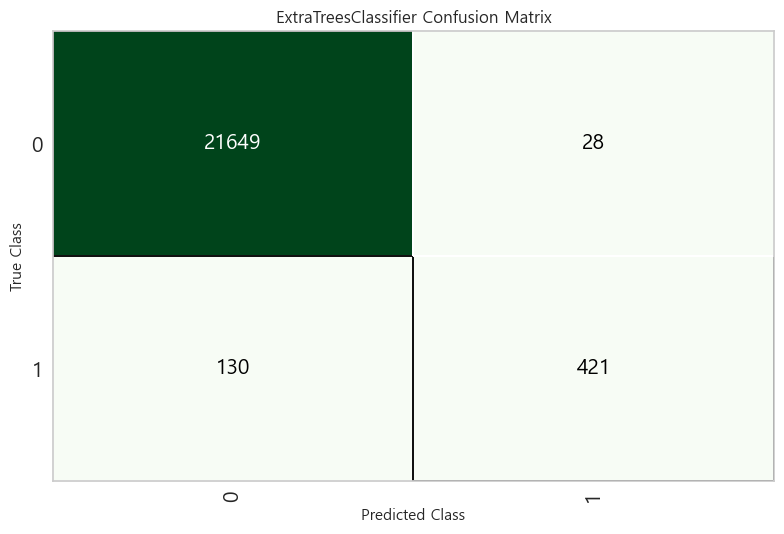

In [117]:
tuned_et = tune_model(create_model('et'), optimize='F1')
plot_model(tuned_et, plot='confusion_matrix')

##### 6) Train/Test 분류 후 최종 모델 학습

###### Train/Test set 분할

In [141]:
from sklearn.model_selection import train_test_split # 운영 가게 분할용

# --- (가정) df_survival, df_prepared 데이터프레임 준비 완료 ---
# df_survival['폐업일'] 컬럼은 datetime 타입이어야 합니다.
# df_survival['폐업여부'] 컬럼이 0 또는 1 값을 가집니다.
# df_prepared['가맹점구분번호'] 컬럼이 있습니다.

# --- 1. 폐업 시점 기준 날짜 설정 ---
cutoff_date = pd.to_datetime('2025-07-31')

# --- 2. 가게 그룹별 ID 목록 생성 ---

# 2-1. 운영 중인 가게 ID 목록
operating_stores_ids = df2[df2['폐업여부'] == 0]['가맹점구분번호'].unique()

# 2-2. 폐업한 가게 ID 목록 (조기 vs 후기)
closed_stores = df2[df2['폐업여부'] == 1]
early_closed_ids = closed_stores[closed_stores['폐업일'] <= cutoff_date]['가맹점구분번호'].unique()
late_closed_ids = closed_stores[closed_stores['폐업일'] > cutoff_date]['가맹점구분번호'].unique()

# 2-3. 운영 중인 가게 ID를 Train/Test로 무작위 분할 (예: 80/20 비율)
if len(operating_stores_ids) > 0:
    op_train_ids, op_test_ids = train_test_split(
        operating_stores_ids,
        test_size=0.2, # Test 비율 20%
        random_state=42 # 결과 재현용 시드
    )
else:
    op_train_ids, op_test_ids = [], []

# --- 3. 최종 Train/Test 가게 ID 목록 결합 ---
train_store_ids = list(early_closed_ids) + list(op_train_ids)
test_store_ids = list(late_closed_ids) + list(op_test_ids)

# --- 4. df_prepared 데이터 필터링 ---
train_eval_data = df_prepared[df_prepared['가맹점구분번호'].isin(train_store_ids)].copy()
test_eval_data = df_prepared[df_prepared['가맹점구분번호'].isin(test_store_ids)].copy()

# --- 5. 결과 확인 ---
print("--- Train 평가셋 구성 ---")
print(f"  - 총 가게 수: {len(train_store_ids)}")
print(f"    - 조기 폐업 (~{cutoff_date.date()}): {len(early_closed_ids)}개")
print(f"    - 운영 중 (80%): {len(op_train_ids)}개")
print(f"  - 총 데이터 포인트 수: {len(train_eval_data)}")
# print(train_eval_data['폐업여부'].value_counts()) # Train 내 폐업/운영 비율 확인 (y 컬럼명 확인 필요)

print("\n--- Test 평가셋 구성 ---")
print(f"  - 총 가게 수: {len(test_store_ids)}")
print(f"    - 후기 폐업 (>{cutoff_date.date()}): {len(late_closed_ids)}개")
print(f"    - 운영 중 (20%): {len(op_test_ids)}개")
print(f"  - 총 데이터 포인트 수: {len(test_eval_data)}")
# print(test_eval_data['폐업여부'].value_counts()) # Test 내 폐업/운영 비율 확인 (y 컬럼명 확인 필요)

print("\n✅ 운영/폐업 데이터 포함 및 폐업 시점 기준 분할 완료.")

--- Train 평가셋 구성 ---
  - 총 가게 수: 3337
    - 조기 폐업 (~2025-07-31): 93개
    - 운영 중 (80%): 3244개
  - 총 데이터 포인트 수: 58802

--- Test 평가셋 구성 ---
  - 총 가게 수: 846
    - 후기 폐업 (>2025-07-31): 34개
    - 운영 중 (20%): 812개
  - 총 데이터 포인트 수: 15289

✅ 운영/폐업 데이터 포함 및 폐업 시점 기준 분할 완료.


In [142]:
final_model_1 = finalize_model(tuned_knn)

In [143]:
from sklearn.metrics import classification_report

print("\n--- Train 평가셋 ( ~25/07 폐업) 성능 검증 ---")
predictions_train = predict_model(final_model_1, data=train_eval_data)

y_true_train = predictions_train['y_6개월후_폐업유무'] # 실제값 컬럼명 확인
y_pred_train = predictions_train['prediction_label'] # 예측값 컬럼명 확인

if len(y_true_train) > 0:
    print(classification_report(y_true_train, y_pred_train, target_names=['정상(0)', '위기(1)']))
else:
    print("Train 평가셋 데이터 없음.")



print("\n--- Test 평가셋 ( 25/07 ~ 폐업) 성능 검증 ---")
predictions_test = predict_model(final_model_1, data=test_eval_data)

y_true_test = predictions_test['y_6개월후_폐업유무'] # 실제값 컬럼명 확인
y_pred_test = predictions_test['prediction_label'] # 예측값 컬럼명 확인

if len(y_true_test) > 0:
    print(classification_report(y_true_test, y_pred_test, target_names=['정상(0)', '위기(1)']))
else:
    print("Test 평가셋 데이터 없음.")


--- Train 평가셋 ( ~25/07 폐업) 성능 검증 ---


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.9510,1.0000,1.0000,0.2972,0.4582,0.4403,0.5313


              precision    recall  f1-score   support

       정상(0)       1.00      0.95      0.97     57583
       위기(1)       0.30      1.00      0.46      1219

    accuracy                           0.95     58802
   macro avg       0.65      0.97      0.72     58802
weighted avg       0.99      0.95      0.96     58802


--- Test 평가셋 ( 25/07 ~ 폐업) 성능 검증 ---


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,K Neighbors Classifier,0.9549,1.0000,1.0000,0.4728,0.6421,0.6213,0.6713


              precision    recall  f1-score   support

       정상(0)       1.00      0.95      0.98     14671
       위기(1)       0.47      1.00      0.64       618

    accuracy                           0.95     15289
   macro avg       0.74      0.98      0.81     15289
weighted avg       0.98      0.95      0.96     15289



In [147]:
final_model_2 = finalize_model(tuned_et)

In [158]:
from pycaret.classification import *

# (clf_setup 완료 가정)
# et_model = create_model('et') # 기본 ET 모델 생성

# max_depth를 5, 10, 15 중에서만 탐색하도록 튜닝
custom_grid_et = {'max_depth': [5, 10, 15]} # 원하는 깊이 리스트

tuned_et_depth_limited = tune_model(
    tuned_et,
    optimize='Recall', # 또는 'F1'
    custom_grid=custom_grid_et,
    n_iter=20 # 탐색 횟수 (custom_grid 크기에 맞춰 조절)
)

# 이제 제한된 깊이 내에서 최적화된 모델로 finalize
final_model_depth_limited = finalize_model(tuned_et_depth_limited)

# (성능 평가 등)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9533,0.9569,0.8140,0.3251,0.4646,0.4449,0.4968
1,0.9555,0.9396,0.7519,0.3277,0.4565,0.4370,0.4784
2,0.9560,0.9374,0.7674,0.3333,0.4648,0.4456,0.4882
3,0.9562,0.9622,0.8516,0.3438,0.4899,0.4713,0.5249
4,0.9599,0.9734,0.8438,0.3649,0.5094,0.4919,0.5394
5,0.9556,0.9614,0.7969,0.3333,0.4700,0.4509,0.4981
6,0.9489,0.9520,0.7734,0.2955,0.4276,0.4064,0.4587
7,0.9450,0.9177,0.6899,0.2665,0.3844,0.3615,0.4070
8,0.9537,0.9420,0.7287,0.3144,0.4393,0.4191,0.4598


Fitting 10 folds for each of 3 candidates, totalling 30 fits


In [160]:
final_model_2 = finalize_model(tuned_et_depth_limited)

In [161]:
from sklearn.metrics import classification_report

print("\n--- Train 평가셋 ( ~25/07 폐업) 성능 검증 ---")
predictions_train = predict_model(final_model_2, data=train_eval_data)

y_true_train = predictions_train['y_6개월후_폐업유무'] # 실제값 컬럼명 확인
y_pred_train = predictions_train['prediction_label'] # 예측값 컬럼명 확인

if len(y_true_train) > 0:
    print(classification_report(y_true_train, y_pred_train, target_names=['정상(0)', '위기(1)']))
else:
    print("Train 평가셋 데이터 없음.")



print("\n--- Test 평가셋 ( 25/07 ~ 폐업) 성능 검증 ---")
predictions_test = predict_model(final_model_2, data=test_eval_data)

y_true_test = predictions_test['y_6개월후_폐업유무'] # 실제값 컬럼명 확인
y_pred_test = predictions_test['prediction_label'] # 예측값 컬럼명 확인

if len(y_true_test) > 0:
    print(classification_report(y_true_test, y_pred_test, target_names=['정상(0)', '위기(1)']))
else:
    print("Test 평가셋 데이터 없음.")


--- Train 평가셋 ( ~25/07 폐업) 성능 검증 ---


              precision    recall  f1-score   support

       정상(0)       1.00      0.96      0.98     57583
       위기(1)       0.33      0.99      0.50      1219

    accuracy                           0.96     58802
   macro avg       0.67      0.97      0.74     58802
weighted avg       0.99      0.96      0.97     58802


--- Test 평가셋 ( 25/07 ~ 폐업) 성능 검증 ---


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9569,0.9926,0.9385,0.4829,0.6377,0.6173,0.6560


              precision    recall  f1-score   support

       정상(0)       1.00      0.96      0.98     14671
       위기(1)       0.48      0.94      0.64       618

    accuracy                           0.96     15289
   macro avg       0.74      0.95      0.81     15289
weighted avg       0.98      0.96      0.96     15289



##### 7) 요인 분석

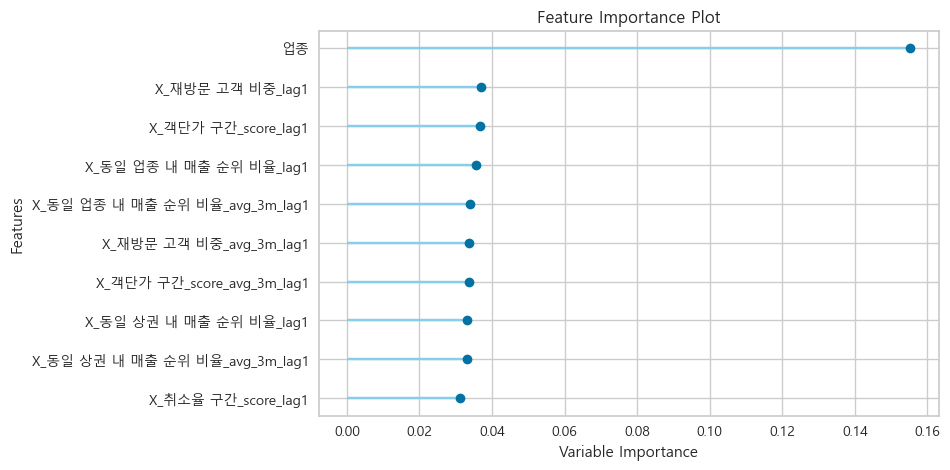

In [164]:
plot_model(final_model_2, plot='feature')

##### 8) 경고수치 예측

In [ ]:
# 4-1. 모델에 사용할 컬럼만 선택 - 피쳐 별

# 정적 변수
static_features = ['가맹점구분번호','업종', '상권']
# 동적 변수
dynamic_features = [col for col in df2.columns if col.startswith('X_')]
# 예측할 목표로 하는 값
target = ['y_6개월후_경고수치']

df_model_input = df2[static_features + dynamic_features + target].copy()

# 4-2. 과거/미래를 계산할 수 없는 'NaN' 행 제거
# (초반 6개월 'warm-up' 기간, 마지막 6개월 'cool-down' 기간이 제거됨)
df_prepared = df_model_input.dropna()

In [95]:
# 5-1. PyCaret 환경 설정
clf_setup = setup(
    data=df_prepared, 
    target='y_6개월후_경고수치',
    session_id=123,
    categorical_features=['업종', '상권'], # 범주형 변수 지정
    ignore_features=['가맹점구분번호'],
    fix_imbalance=True,          # 불균형 데이터 처리 (SMOTE)
    verbose=False                # 로그 최소화
)

# 5-2. 모델 비교 (Recall: 위기를 놓치지 않는 순서로 정렬)
best_model = compare_models(sort='Recall')
best_model

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9058,0.9652,0.9058,0.8953,0.8969,0.7326,0.7347,11.0090
lightgbm,Light Gradient Boosting Machine,0.9027,0.9611,0.9027,0.8941,0.8937,0.7255,0.7275,10.4500
catboost,CatBoost Classifier,0.9020,0.9620,0.9020,0.8936,0.8950,0.7277,0.7289,133.1790
rf,Random Forest Classifier,0.8913,0.9709,0.8913,0.8849,0.8872,0.7056,0.7060,28.6380
et,Extra Trees Classifier,0.8836,0.9701,0.8836,0.8712,0.8765,0.6811,0.6816,10.6500
gbc,Gradient Boosting Classifier,0.8635,0.0000,0.8635,0.8742,0.8668,0.6512,0.6537,464.5630
dt,Decision Tree Classifier,0.8389,0.8603,0.8389,0.8666,0.8515,0.5940,0.5966,3.8890
ada,Ada Boost Classifier,0.7985,0.0000,0.7985,0.8392,0.8159,0.5160,0.5226,14.6010
dummy,Dummy Classifier,0.7857,0.5000,0.7857,0.6173,0.6914,0.0000,0.0000,0.3640
knn,K Neighbors Classifier,0.7662,0.9093,0.7662,0.8753,0.8139,0.4911,0.5089,6.6740


XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)